Projet : Détection des maladies des plantes par image

Étape : Préparation des données

Framework : PyTorch

In [1]:
!pip install -q torch torchvision pillow matplotlib pandas scikit-learn

In [2]:
import os
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

print("Tout est prêt !")

Tout est prêt !


Monter drive

In [3]:
from google.colab import drive
import os

drive.mount('/content/drive')
print(os.listdir('/content/drive/MyDrive/IA'))

Mounted at /content/drive
['plant_disease']


Récupérer le dataset depuis Drive

In [4]:
import zipfile
from pathlib import Path

dataset_zip = Path(
    "/content/drive/MyDrive/IA/plant_disease/dataset.zip"
)

extract_path = Path("/content/dataset")

with zipfile.ZipFile(dataset_zip, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extrait dans :", extract_path)
for path in extract_path.iterdir():
    print(path)

Dataset extrait dans : /content/dataset
/content/dataset/Tomate_Alternariose
/content/dataset/Tomate_Saine
/content/dataset/Tomate_Mildiou


Compter les images par classe

In [ ]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
dataset_path = Path("/content/dataset")

class_counts = {}

for class_dir in dataset_path.iterdir():
    if class_dir.is_dir():
        count = sum(
            1 for file in class_dir.rglob("*")
            if file.suffix.lower() in image_extensions
        )
        class_counts[class_dir.name] = count

df_counts = pd.DataFrame(
    list(class_counts.items()),
    columns=["Classe", "Nombre d'images"]
)

# class_counts
df_counts

,Classe,Nombre d'images
0,Tomate_Alternariose,1000
1,Tomate_Saine,999
2,Tomate_Mildiou,1000


Visualiser la distribution

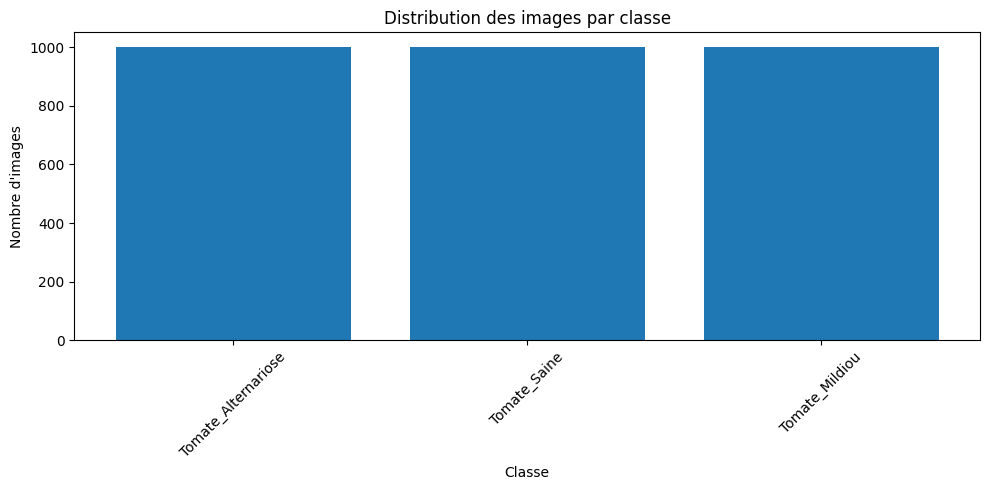

In [6]:
plt.figure(figsize=(10, 5))

plt.bar(df_counts["Classe"], df_counts["Nombre d'images"])

plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.title("Distribution des images par classe")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Vérifier les images invalides

In [7]:
invalid_images = []
nb_image = 0

for class_dir in dataset_path.iterdir():
    if not class_dir.is_dir():
        continue

    for image_path in class_dir.rglob("*"):
        nb_image += 1
        if image_path.suffix.lower() not in image_extensions:
            continue

        try:
            with Image.open(image_path) as img:
                img.verify()
        except Exception:
            invalid_images.append(str(image_path))

print("Nombre d'images invalides :", len(invalid_images))
print("Images traitées :", nb_image)
for image in invalid_images:
    print(image)

Nombre d'images invalides : 0
Images traitées : 2999


# Vérifier les dimensions des images

In [8]:
dimensions = []

for class_dir in dataset_path.iterdir():
    if not class_dir.is_dir():
        continue

    for image_path in class_dir.rglob("*"):
        if image_path.suffix.lower() not in image_extensions:
            continue

        try:
            with Image.open(image_path) as img:
                dimensions.append({
                    "classe": class_dir.name,
                    "largeur": img.width,
                    "hauteur": img.height
                })
        except:
            pass

df_dimensions = pd.DataFrame(dimensions)

df_dimensions.head()

,classe,largeur,hauteur
0,Tomate_Alternariose,256,256
1,Tomate_Alternariose,256,256
2,Tomate_Alternariose,256,256
3,Tomate_Alternariose,256,256
4,Tomate_Alternariose,256,256


In [9]:
df_dimensions.describe()

,largeur,hauteur
count,2999.0,2999.0
mean,256.0,256.0
std,0.0,0.0
min,256.0,256.0
25%,256.0,256.0
50%,256.0,256.0
75%,256.0,256.0
max,256.0,256.0


# Voir quelques images
Nous allons afficher quelques images aléatoires.

In [10]:
all_images = []

for class_dir in dataset_path.iterdir():
    if not class_dir.is_dir():
        continue

    for image_path in class_dir.rglob("*"):
        if image_path.suffix.lower() in image_extensions:
            all_images.append((image_path, class_dir.name))

random.shuffle(all_images)

for image_path, label in all_images[:9]:
    print(label, "→", image_path)

Tomate_Mildiou → /content/dataset/Tomate_Mildiou/image (510).JPG
Tomate_Saine → /content/dataset/Tomate_Saine/image (223).JPG
Tomate_Alternariose → /content/dataset/Tomate_Alternariose/image (782).JPG
Tomate_Saine → /content/dataset/Tomate_Saine/image (716).JPG
Tomate_Saine → /content/dataset/Tomate_Saine/image (154).JPG
Tomate_Alternariose → /content/dataset/Tomate_Alternariose/image (174).JPG
Tomate_Mildiou → /content/dataset/Tomate_Mildiou/image (592).JPG
Tomate_Mildiou → /content/dataset/Tomate_Mildiou/image (346).JPG
Tomate_Alternariose → /content/dataset/Tomate_Alternariose/image (693).JPG


# Afficher 9 images
il faut regarder attentivement :

* Les images correspondent-elles réellement aux classes ?
* Les feuilles sont-elles visibles ?
* Les photos sont-elles de bonne qualité ?
* Y a-t-il des images complètement différentes ?
* Y a-t-il des images qui ne montrent pas une feuille ?

Cette vérification humaine reste importante.

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, (image_path, label) in zip(axes.flat, all_images[:9]):
    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Vérifier le déséquilibre des classes
Nous allons calculer le rapport entre la classe la plus représentée et la moins représentée.

In [12]:
max_count = df_counts["Nombre d'images"].max()
min_count = df_counts["Nombre d'images"].min()

print("Classe la plus représentée :", max_count)
print("Classe la moins représentée :", min_count)
print("Ratio :", round(max_count / min_count, 2))

Classe la plus représentée : 1000
Classe la moins représentée : 999
Ratio : 1.0


# Rechercher les doublons
Pour un premier contrôle simple, nous pouvons calculer un hash des fichiers.

In [13]:
import hashlib

hashes = {}
duplicates = []

for class_dir in dataset_path.iterdir():
    if not class_dir.is_dir():
        continue

    for image_path in class_dir.rglob("*"):
        if image_path.suffix.lower() not in image_extensions:
            continue

        try:
            file_hash = hashlib.md5(image_path.read_bytes()).hexdigest()

            if file_hash in hashes:
                duplicates.append(
                    (str(image_path), hashes[file_hash])
                )
            else:
                hashes[file_hash] = str(image_path)

        except:
            pass

print("Nombre de doublons exacts :", len(duplicates))

Nombre de doublons exacts : 4


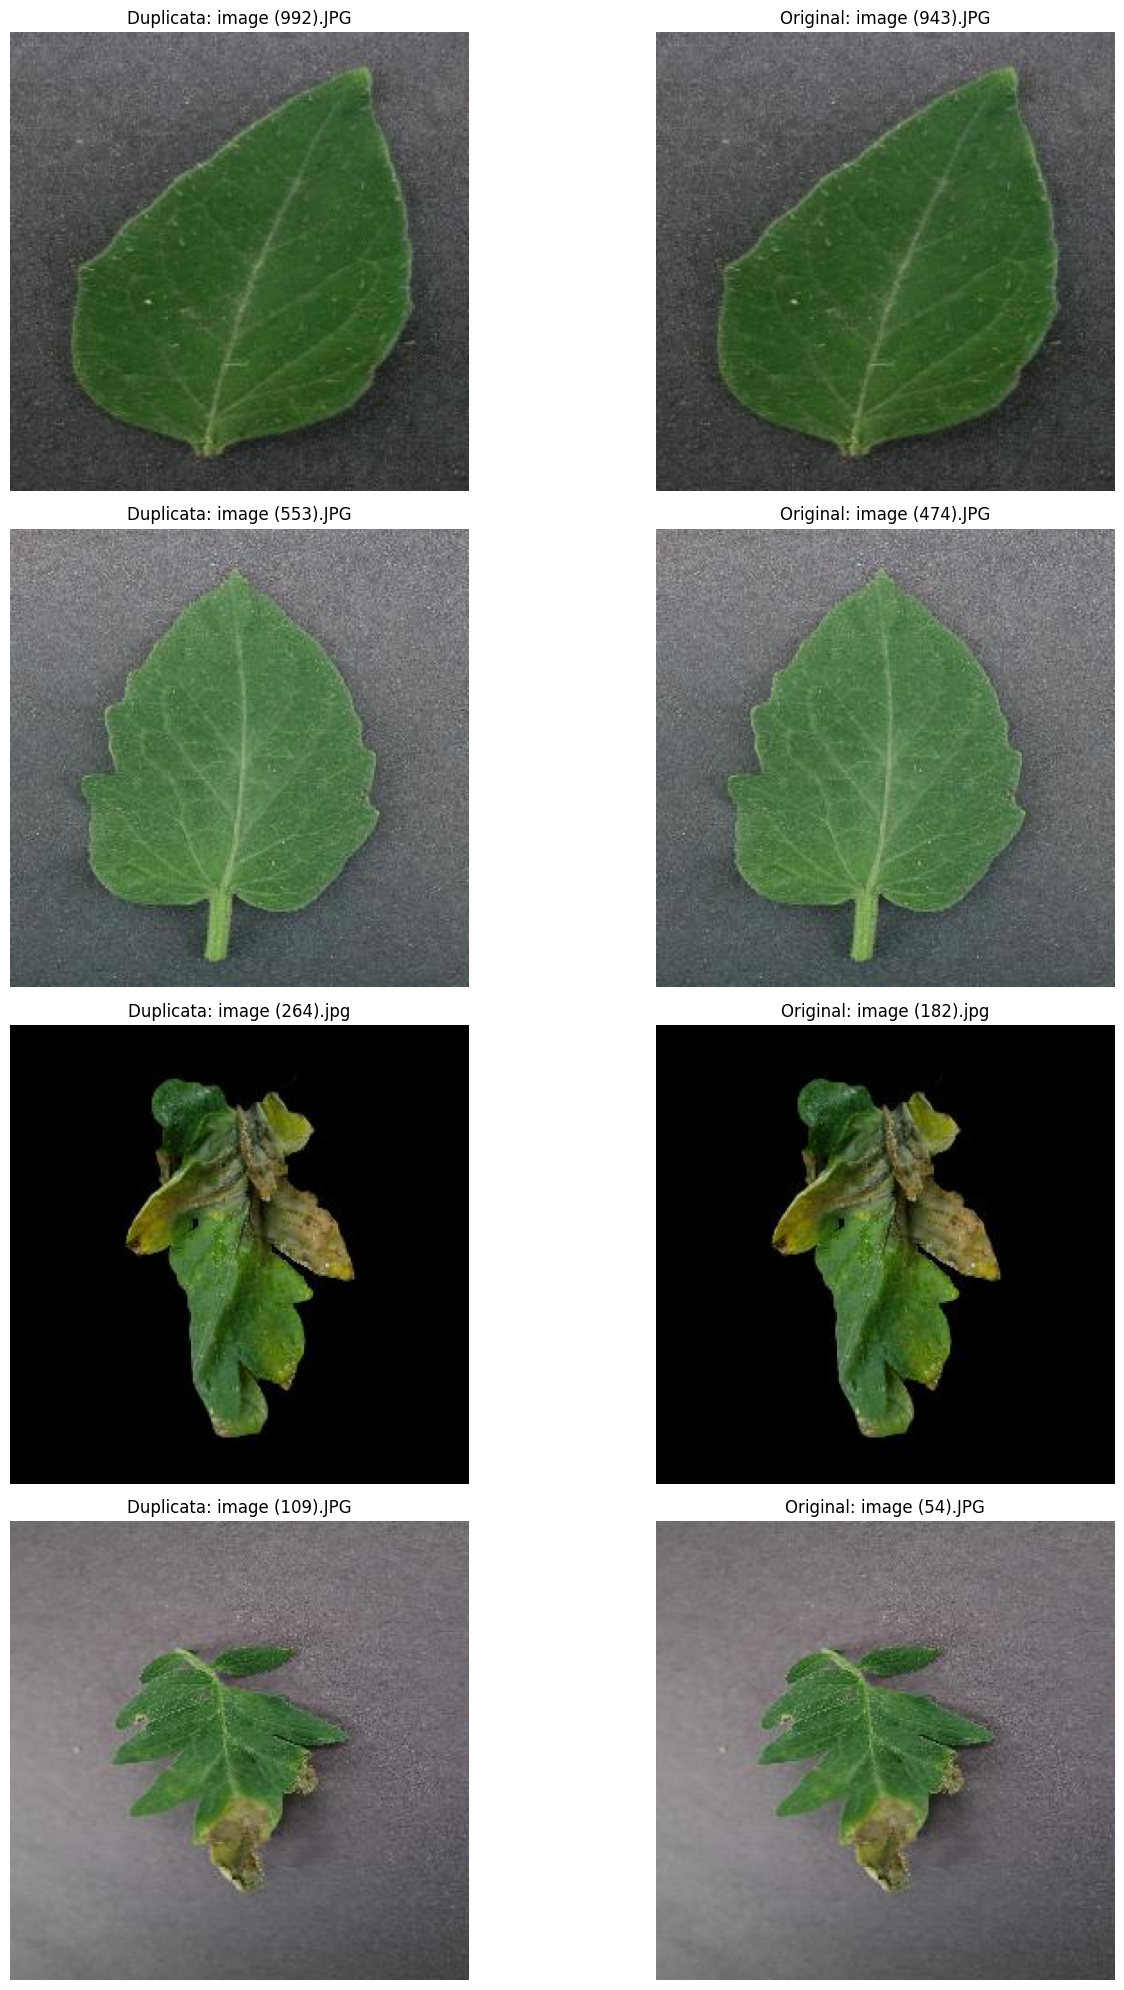

In [14]:
if len(duplicates) > 0:
    num_duplicates = len(duplicates)
    fig, axes = plt.subplots(num_duplicates, 2, figsize=(15, 5 * num_duplicates))

    for i, (dup_path, original_path) in enumerate(duplicates):
        # Open the duplicate image
        img_dup = Image.open(dup_path)
        # Open the original image that matched the hash
        img_original = Image.open(original_path)

        # Display duplicate image
        if num_duplicates == 1:
            ax1 = axes[0]
            ax2 = axes[1]
        else:
            ax1 = axes[i, 0]
            ax2 = axes[i, 1]

        ax1.imshow(img_dup)
        ax1.set_title(f"Duplicata: {Path(dup_path).name}")
        ax1.axis("off")

        # Display original image
        ax2.imshow(img_original)
        ax2.set_title(f"Original: {Path(original_path).name}")
        ax2.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Aucun doublon trouvé à afficher.")

# Création Train / Validation / Tes

In [15]:
#Pour que votre séparation soit reproductible: fixer le random seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

#Ainsi, si nous relançons notre notebook, nous pourrons retrouver la même séparation.

#Créer les dossiers
processed_path = Path("/content/processed_dataset")

train_path = processed_path / "train"
val_path = processed_path / "val"
test_path = processed_path / "test"

for path in [train_path, val_path, test_path]:
    path.mkdir(parents=True, exist_ok=True)


TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

for class_dir in dataset_path.iterdir():

    if not class_dir.is_dir():
        continue

    images = [
        p for p in class_dir.rglob("*")
        if p.suffix.lower() in image_extensions
    ]

    random.shuffle(images)

    n = len(images)

    train_end = int(n * TRAIN_RATIO)
    val_end = train_end + int(n * VAL_RATIO)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    for destination, image_list in [
        (train_path, train_images),
        (val_path, val_images),
        (test_path, test_images)
    ]:

        class_destination = destination / class_dir.name
        class_destination.mkdir(parents=True, exist_ok=True)

        for image in image_list:
            shutil.copy2(
                image,
                class_destination / image.name
            )

print("Séparation terminée.")

Séparation terminée.


# Vérifier la séparation

In [16]:
for split in ["train", "val", "test"]:

    split_path = processed_path / split

    print(f"\n--- {split.upper()} ---")

    for class_dir in split_path.iterdir():

        if class_dir.is_dir():

            count = sum(
                1 for p in class_dir.iterdir()
                if p.suffix.lower() in image_extensions
            )

            print(class_dir.name, ":", count)


--- TRAIN ---
Tomate_Alternariose : 700
Tomate_Saine : 699
Tomate_Mildiou : 700

--- VAL ---
Tomate_Alternariose : 150
Tomate_Saine : 149
Tomate_Mildiou : 150

--- TEST ---
Tomate_Alternariose : 150
Tomate_Saine : 151
Tomate_Mildiou : 150


# Création des transformations PyTorch

In [17]:
from torchvision.models import  EfficientNet_B0_Weights
weights = EfficientNet_B0_Weights.DEFAULT

#Comme nous utilisons un modèle pré-entraîné,
#il est préférable d'utiliser la normalisation attendue par les poids pré-entraînés.
mean = weights.transforms().mean
std = weights.transforms().std

#Entrainement
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=mean,
        std=std
    )
])

In [18]:
#Validation et test
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=mean,
        std=std
    )
])

# Charger les datasets avec ImageFolder

In [19]:

train_dataset = ImageFolder(
    root=train_path,
    transform=train_transform
)

val_dataset = ImageFolder(
    root=val_path,
    transform=val_test_transform
)

test_dataset = ImageFolder(
    root=test_path,
    transform=val_test_transform
)

print("Classes :", train_dataset.classes)
print("Correspondance :", train_dataset.class_to_idx)

Classes : ['Tomate_Alternariose', 'Tomate_Mildiou', 'Tomate_Saine']
Correspondance : {'Tomate_Alternariose': 0, 'Tomate_Mildiou': 1, 'Tomate_Saine': 2}


# Vérifier si les classes sont identiques

In [20]:
print(
    "Train == Validation :",
    train_dataset.classes == val_dataset.classes
)

print(
    "Train == Test :",
    train_dataset.classes == test_dataset.classes
)

Train == Validation : True
Train == Test : True


# Créer les DataLoaders

In [21]:
#from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

# Vérifier un batch

In [22]:
images, labels = next(iter(train_loader))

print("Images :", images.shape)
print("Labels :", labels.shape)

Images : torch.Size([32, 3, 224, 224])
Labels : torch.Size([32])


# Vérification visuelle finale

In [23]:
def denormalize(image):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    image = image * std + mean

    return torch.clamp(image, 0, 1)

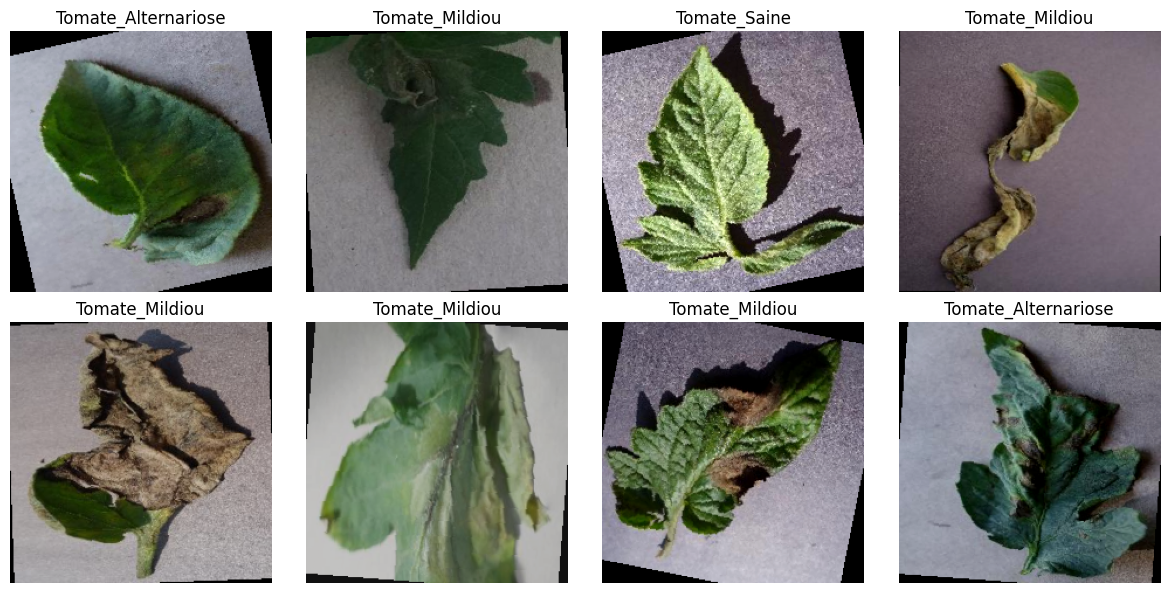

In [24]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, image, label in zip(
    axes.flat,
    images[:8],
    labels[:8]
):

    image = denormalize(image)

    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [25]:
import torch

print("PyTorch version :", torch.__version__)
print("GPU disponible :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

PyTorch version : 2.11.0+cu128
GPU disponible : True
GPU : Tesla T4


# Entrainement

In [26]:
!pip install seaborn

In [27]:
DATASET_DIR = "/content/processed_dataset"
MODEL_DIR = "/content/models"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")
TEST_DIR = os.path.join(DATASET_DIR, "test")

print("Train :", TRAIN_DIR)
print("Validation :", VAL_DIR)
print("Test :", TEST_DIR)

Train : /content/processed_dataset/train
Validation : /content/processed_dataset/val
Test : /content/processed_dataset/test


# Vérifier que les dossiers existe

In [28]:
for directory in [DATASET_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(directory, "→", os.path.exists(directory))
#Si on obtien quelque chose de false, il faut tous arrêter

/content/processed_dataset → True
/content/processed_dataset/train → True
/content/processed_dataset/val → True
/content/processed_dataset/test → True


# Vérifier automatiquement les classes

In [29]:
classes = sorted(os.listdir(TRAIN_DIR))

print("Classes :")
for i, class_name in enumerate(classes):
    print(i, "→", class_name)

print("Nombre de classes :", len(classes))

Classes :
0 → Tomate_Alternariose
1 → Tomate_Mildiou
2 → Tomate_Saine
Nombre de classes : 3


# Construire EfficientNet-B0

In [30]:
import json
import copy
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

#Remplacer la dervière couche
num_classes = len(train_dataset.classes)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 181MB/s]


# Envoyer le modèle sur le GPU

In [31]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print("Modèle chargé sur :", device)

Modèle chargé sur : cuda


# Définir Loss et Optimizer

In [32]:
criterion = nn.CrossEntropyLoss()

#Nous commençons avec une configuration simple.
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# Paramètres de l'entraînement

In [33]:
NUM_EPOCHS = 10

LEARNING_RATE = 0.001

print("Epochs :", NUM_EPOCHS)
print("Learning rate :", LEARNING_RATE)
print("Batch size :", BATCH_SIZE)

Epochs : 10
Learning rate : 0.001
Batch size : 32


# Préparer les historiques

In [34]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0

best_model_weights = copy.deepcopy(
    model.state_dict()
)

# Fonction d'entraînement

In [35]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        _, predictions = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

    epoch_loss = running_loss / total

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

# Fonction de validation

In [36]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            _, predictions = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predictions == labels
            ).sum().item()

    epoch_loss = running_loss / total

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

# Lancer le premier entraînement

In [37]:
for epoch in range(NUM_EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

        print(
            "⭐ Nouveau meilleur modèle !"
        )

Epoch [1/10] | Train Loss: 0.2076 | Train Acc: 0.9238 | Val Loss: 0.0798 | Val Acc: 0.9755
⭐ Nouveau meilleur modèle !
Epoch [2/10] | Train Loss: 0.0499 | Train Acc: 0.9833 | Val Loss: 0.0544 | Val Acc: 0.9889
⭐ Nouveau meilleur modèle !
Epoch [3/10] | Train Loss: 0.0606 | Train Acc: 0.9828 | Val Loss: 0.0328 | Val Acc: 0.9911
⭐ Nouveau meilleur modèle !
Epoch [4/10] | Train Loss: 0.0258 | Train Acc: 0.9890 | Val Loss: 0.0584 | Val Acc: 0.9844
Epoch [5/10] | Train Loss: 0.0474 | Train Acc: 0.9871 | Val Loss: 0.0146 | Val Acc: 0.9933
⭐ Nouveau meilleur modèle !
Epoch [6/10] | Train Loss: 0.0273 | Train Acc: 0.9929 | Val Loss: 0.0113 | Val Acc: 0.9933
Epoch [7/10] | Train Loss: 0.0230 | Train Acc: 0.9924 | Val Loss: 0.0337 | Val Acc: 0.9911
Epoch [8/10] | Train Loss: 0.0171 | Train Acc: 0.9943 | Val Loss: 0.0058 | Val Acc: 0.9978
⭐ Nouveau meilleur modèle !
Epoch [9/10] | Train Loss: 0.0527 | Train Acc: 0.9862 | Val Loss: 0.0330 | Val Acc: 0.9844
Epoch [10/10] | Train Loss: 0.0112 | Trai

# Restaurer le meilleur modèle

In [38]:
model.load_state_dict(
    best_model_weights
)

print(
    "Meilleur modèle restauré."
)

print(
    "Meilleure validation accuracy :",
    f"{best_val_accuracy * 100:.2f}%"
)

Meilleur modèle restauré.
Meilleure validation accuracy : 99.78%


# Sauvegarder le modèle

In [39]:
MODEL_DIR_DRIVE = "/content/drive/MyDrive/IA/plant_disease/models"

os.makedirs(
    MODEL_DIR_DRIVE,
    exist_ok=True
)

MODEL_PATH = os.path.join(
    MODEL_DIR_DRIVE,
    "efficientnet_b0_v1.pt"
)

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print(
    "Modèle sauvegardé ici :"
)

print(MODEL_PATH)

Modèle sauvegardé ici :
/content/drive/MyDrive/IA/plant_disease/models/efficientnet_b0_v1.pt


# Sauvegarder les classes
Le modèle connaît seulement des numéros :

0
1
2
3
...

Il faut donc conserver la correspondance

In [40]:
CLASS_NAMES_PATH = os.path.join(
    MODEL_DIR_DRIVE,
    "classes.json"
)

with open(
    CLASS_NAMES_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        train_dataset.classes,
        f,
        ensure_ascii=False,
        indent=4
    )

print(
    "Classes sauvegardées :",
    CLASS_NAMES_PATH
)

Classes sauvegardées : /content/drive/MyDrive/IA/plant_disease/models/classes.json


# Visualiser l'évolution de l'accuracy

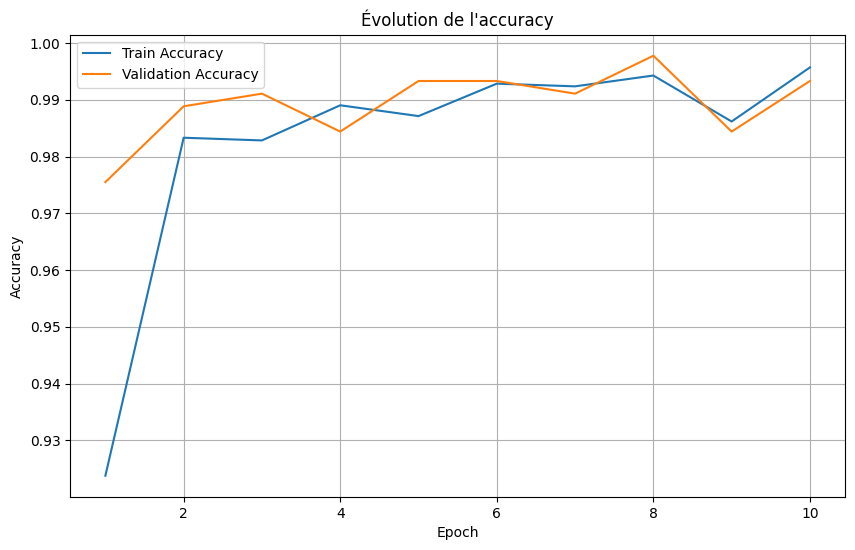

In [41]:
epochs_range = range(
    1,
    NUM_EPOCHS + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Évolution de l'accuracy"
)

plt.legend()

plt.grid()

plt.show()

# Visualiser la Loss

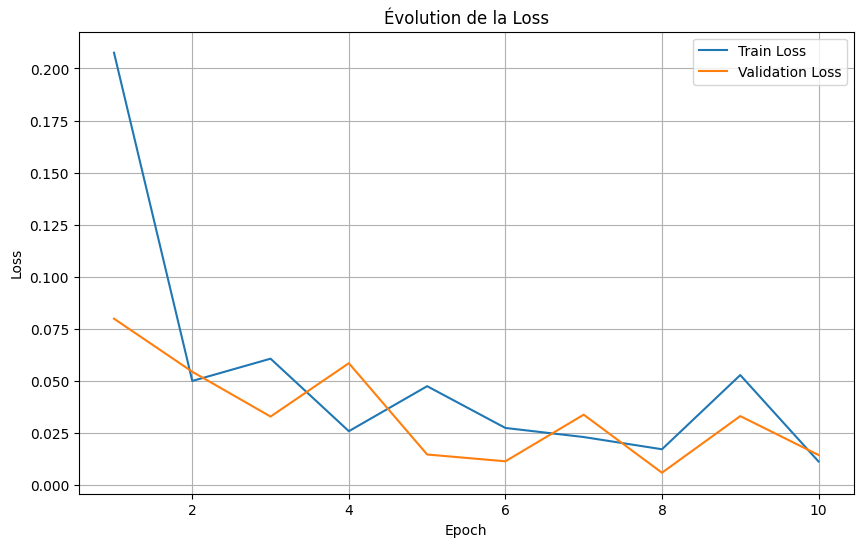

In [42]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs_range,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Évolution de la Loss"
)

plt.legend()

plt.grid()

plt.show()

# Comment interpréter ces graphiques ?
## Cas idéal
Train accuracy     ↗
Validation accuracy ↗

Les deux progressent.

## Cas d'overfitting
Train accuracy       → 99 %
Validation accuracy  → 75 %

et :

Train loss       ↓
Validation loss  ↑

Le modèle mémorise trop les données d'entraînement.

# Évaluation finale sur TEST

In [43]:
test_loss, test_accuracy = validate(
    model,
    test_loader,
    criterion,
    device
)

print(
    f"Test Loss : {test_loss:.4f}"
)

print(
    f"Test Accuracy : {test_accuracy * 100:.2f}%"
)

Test Loss : 0.0177
Test Accuracy : 99.33%


# Récupérer toutes les prédictions
Pour calculer Precision, Recall, F1 et la matrice de confusion

In [44]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predictions = torch.max(
            outputs,
            1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

# Calculer l'accuracy avec sklearn

In [45]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(
    f"Accuracy : {accuracy * 100:.2f}%"
)

Accuracy : 99.33%


# Classification Report

In [46]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=train_dataset.classes,
        digits=4
    )
)

                     precision    recall  f1-score   support

Tomate_Alternariose     1.0000    0.9800    0.9899       150
     Tomate_Mildiou     0.9804    1.0000    0.9901       150
       Tomate_Saine     1.0000    1.0000    1.0000       151

           accuracy                         0.9933       451
          macro avg     0.9935    0.9933    0.9933       451
       weighted avg     0.9935    0.9933    0.9933       451



# Matrice de confusion
Elle permet de répondre à :

Quelles maladies sont le plus souvent confondues ?

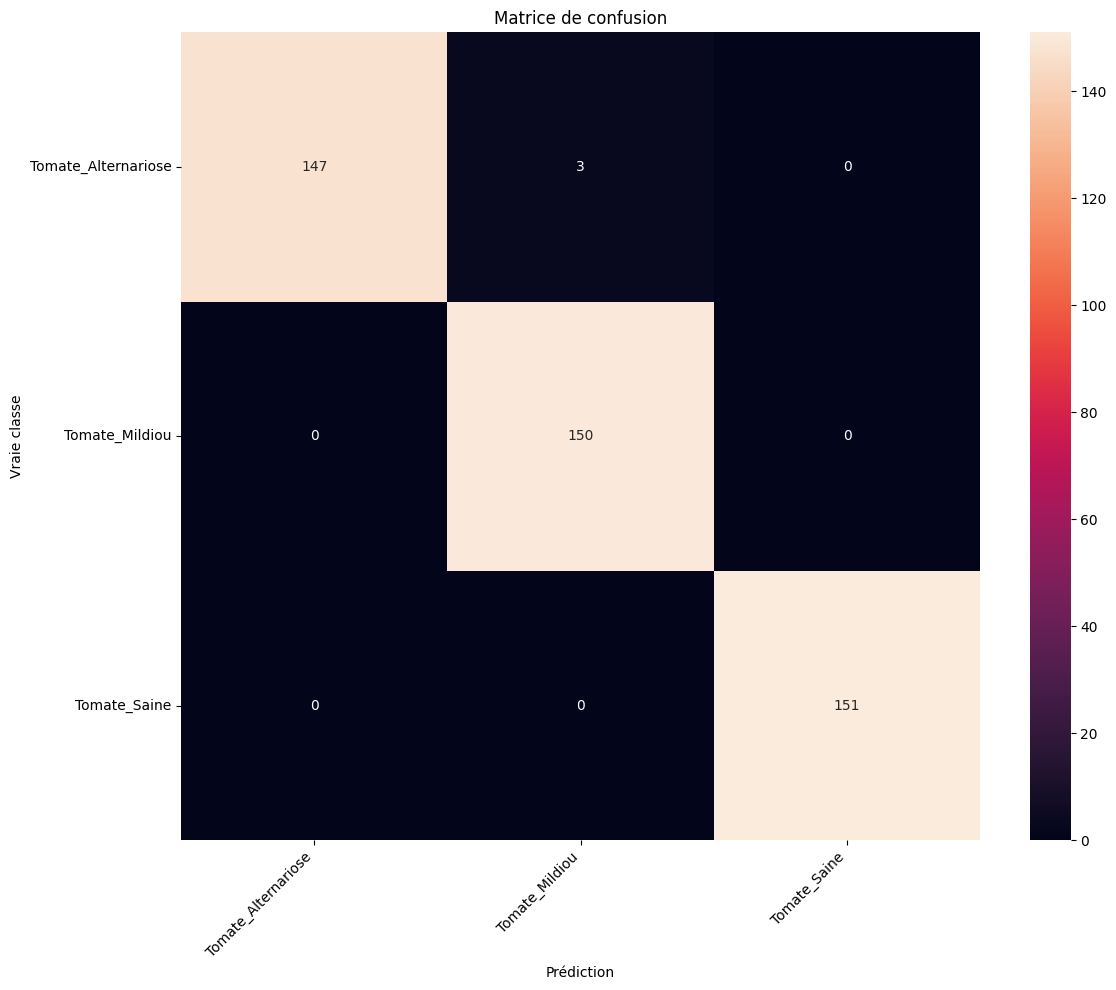

In [47]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")

plt.title(
    "Matrice de confusion"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

# Créer la fonction de prédiction

In [48]:
def predict_image(
    image_path,
    model,
    class_names,
    device
):

    image = Image.open(
        image_path
    ).convert("RGB")

    image_tensor = val_test_transform(
        image
    )

    image_tensor = image_tensor.unsqueeze(0)

    image_tensor = image_tensor.to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(
            image_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

    predicted_class = class_names[
        prediction.item()
    ]

    confidence = confidence.item()

    return predicted_class, confidence

# Tester une image

In [56]:
image_files = [
    file
    for file in Path(TEST_DIR).rglob("*")
    if file.suffix.lower() in image_extensions
]

example_image = image_files[10]

print(
    "Image :",
    example_image
)

Image : /content/processed_dataset/test/Tomate_Alternariose/image (988).JPG


# Faire la prédiction

In [57]:
prediction, confidence = predict_image(
    example_image,
    model,
    train_dataset.classes,
    device
)

print("Prédiction :", prediction)
print(
    "Confiance :",
    f"{confidence * 100:.2f}%"
)

Prédiction : Tomate_Alternariose
Confiance : 93.77%


# Afficher l'image avec la prédiction

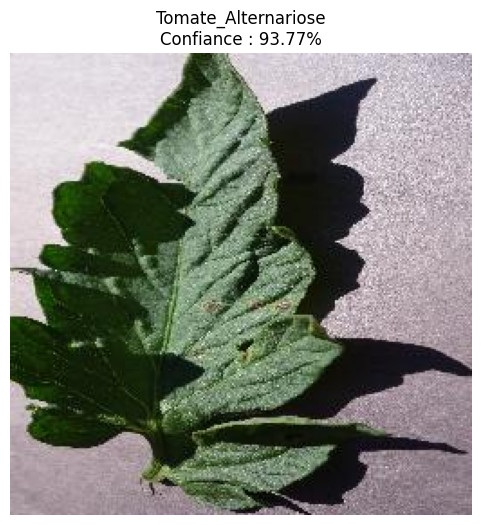

In [58]:
image = Image.open(
    example_image
).convert("RGB")

plt.figure(figsize=(6, 6))

plt.imshow(image)

plt.title(
    f"{prediction}\n"
    f"Confiance : {confidence * 100:.2f}%"
)

plt.axis("off")

plt.show()

# Sauvegarder les informations du modèle

In [59]:
model_info = {
    "model": "EfficientNet-B0",
    "version": "v1",
    "num_classes": num_classes,
    "classes": train_dataset.classes,
    "image_size": [224, 224],
    "batch_size": BATCH_SIZE,
    "epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "best_validation_accuracy": best_val_accuracy,
    "test_accuracy": test_accuracy
}

In [60]:
INFO_PATH = os.path.join(
    MODEL_DIR_DRIVE,
    "model_info.json"
)

with open(
    INFO_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        model_info,
        f,
        ensure_ascii=False,
        indent=4
    )

print(
    "Informations sauvegardées :",
    INFO_PATH
)

Informations sauvegardées : /content/drive/MyDrive/IA/plant_disease/models/model_info.json


# Vérifier les fichiers créés

In [62]:
print("Fichiers du modèle :")

for file in Path(MODEL_DIR_DRIVE).iterdir():
    print(
        f"📄 {file.name} "
        f"({file.stat().st_size / 1024 / 1024:.2f} MB)"
    )

Fichiers du modèle :
📄 efficientnet_b0_v1.pt (15.59 MB)
📄 classes.json (0.00 MB)
📄 model_info.json (0.00 MB)


# Résumé automatique

In [63]:
print("=" * 60)
print("🌱 RÉSULTATS DU PREMIER MODÈLE")
print("=" * 60)

print(f"Modèle              : EfficientNet-B0")
print(f"Nombre de classes   : {num_classes}")
#print(f"Images train        : {total_train}")
#print(f"Images validation   : {total_val}")
#print(f"Images test         : {total_test}")
print(f"Epochs              : {NUM_EPOCHS}")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Learning rate       : {LEARNING_RATE}")
print(
    f"Validation accuracy : "
    f"{best_val_accuracy * 100:.2f}%"
)
print(
    f"Test accuracy       : "
    f"{test_accuracy * 100:.2f}%"
)

print("=" * 60)

🌱 RÉSULTATS DU PREMIER MODÈLE
Modèle              : EfficientNet-B0
Nombre de classes   : 3
Epochs              : 10
Batch size          : 32
Learning rate       : 0.001
Validation accuracy : 99.78%
Test accuracy       : 99.33%
